# Mirror-CFE: Chest X-Ray (No Finding vs. Infiltration)
**Methode:** Mirror-CFE nach Chowdhury et al. (2025)

## 1. Imports & Konfiguration

In [1]:
import os
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import GroupShuffleSplit

torch.manual_seed(2024)
np.random.seed(2024)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Gerät:', DEVICE)

CSV_PATH   = '../input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
BBOX_PATH  = '../input/datasets/organizations/nih-chest-xrays/data/BBox_List_2017.csv'
IMAGE_GLOB = '../input/datasets/organizations/nih-chest-xrays/data/images_*/images/*.png'
PTH_PATH   = '/kaggle/input/models/alexandernigg/resnet18-updated/pytorch/default/1/resnet18_xray_final.pth'

IMG_SIZE      = 224
BATCH_SIZE    = 16
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
CLASS_NAMES   = {0: 'No Finding', 1: 'Infiltration'}

print('CSV    vorhanden:', os.path.exists(CSV_PATH))
print('BBox   vorhanden:', os.path.exists(BBOX_PATH))
print('Modell vorhanden:', os.path.exists(PTH_PATH))

Gerät: cuda
CSV    vorhanden: True
BBox   vorhanden: True
Modell vorhanden: True


## 2. Datensatz laden

In [2]:
all_xray_df = pd.read_csv(CSV_PATH)
all_xray_df['Patient Age'] = all_xray_df['Patient Age'].astype(str).str.rstrip('Y').astype(int)
all_image_paths = {os.path.basename(x): x for x in glob(IMAGE_GLOB)}
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)

def assign_binary_label(finding: str):
    if finding == 'No Finding':
        return 0
    elif 'Infiltration' in finding:
        return 1
    return None

all_xray_df['binary_label'] = all_xray_df['Finding Labels'].map(assign_binary_label)
all_xray_df = all_xray_df.dropna(subset=['binary_label', 'path']).copy()
all_xray_df['binary_label'] = all_xray_df['binary_label'].astype(int)

counts = all_xray_df['binary_label'].value_counts().rename({0: 'No Finding', 1: 'Infiltration'})
print('Klassenverteilung:')
print(counts)

Klassenverteilung:
binary_label
No Finding      60361
Infiltration    19894
Name: count, dtype: int64


## 3. Bounding Boxes laden

In [3]:
bbox_df = pd.read_csv(BBOX_PATH)
bbox_df = bbox_df.rename(columns={'Bbox [x': 'x', 'y': 'y', 'w': 'w', 'h]': 'h'})[
    ['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']]
infiltrate_bbox = bbox_df[bbox_df['Finding Label'] == 'Infiltrate'].copy()
scale = IMG_SIZE / 1024.0
for col in ['x', 'y', 'w', 'h']:
    infiltrate_bbox[col] = infiltrate_bbox[col] * scale
bbox_lookup = infiltrate_bbox.groupby('Image Index').first()[['x', 'y', 'w', 'h']].to_dict('index')
print(f'Infiltrate BBoxes: {len(bbox_lookup)} Bilder')

Infiltrate BBoxes: 123 Bilder


## 4. Train/Test Split (patientenbasiert)

In [4]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(splitter.split(all_xray_df, groups=all_xray_df['Patient ID']))
train_df = all_xray_df.iloc[train_idx].reset_index(drop=True)
temp_df  = all_xray_df.iloc[temp_idx].reset_index(drop=True)
splitter2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(splitter2.split(temp_df, groups=temp_df['Patient ID']))
valid_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df  = temp_df.iloc[test_idx].reset_index(drop=True)
assert len(set(train_df['Patient ID']) & set(test_df['Patient ID'])) == 0
print(f'Train: {len(train_df)}  Val: {len(valid_df)}  Test: {len(test_df)}')

Train: 56768  Val: 11926  Test: 11561


## 5. DataLoader

In [5]:
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class XRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = torch.tensor(row['binary_label'], dtype=torch.float32)
        fname = row['Image Index']
        if self.transform:
            image = self.transform(image)
        return image, label, fname

test_dataset = XRayDataset(test_df, transform=eval_transforms)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=False)
print(f'Test-Batches: {len(test_loader)}')

Test-Batches: 723


## 6. Modell laden

In [6]:
from collections import OrderedDict
from functools import partial

class Conv2dAuto(nn.Conv2d):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.padding = (self.kernel_size[0] // 2, self.kernel_size[1] // 2)

conv3x3 = partial(Conv2dAuto, kernel_size=3, bias=False)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.blocks   = nn.Identity()
        self.shortcut = nn.Identity()
    def forward(self, x):
        residual = self.shortcut(x) if self.should_apply_shortcut else x
        x = self.blocks(x)
        x += residual
        return x
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.out_channels

class ResNetResidualBlock(ResidualBlock):
    def __init__(self, in_channels, out_channels, expansion=1,
                 downsampling=1, conv=conv3x3, *args, **kwargs):
        super().__init__(in_channels, out_channels)
        self.expansion    = expansion
        self.downsampling = downsampling
        self.conv         = conv
        self.shortcut = (
            nn.Sequential(OrderedDict({
                'conv': nn.Conv2d(self.in_channels, self.expanded_channels,
                                  kernel_size=1, stride=self.downsampling, bias=False),
                'bn':   nn.BatchNorm2d(self.expanded_channels)
            }))
            if self.should_apply_shortcut else None
        )
    @property
    def expanded_channels(self):
        return self.out_channels * self.expansion
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.expanded_channels

def conv_bn(in_channels, out_channels, conv, *args, **kwargs):
    return nn.Sequential(OrderedDict({
        'conv': conv(in_channels, out_channels, *args, **kwargs),
        'bn':   nn.BatchNorm2d(out_channels)
    }))

class ResNetBasicBlock(ResNetResidualBlock):
    expansion = 1
    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels,
                    conv=self.conv, bias=False, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels,
                    conv=self.conv, bias=False),
        )

class ResNetLayer(nn.Module):
    def __init__(self, in_channels, out_channels, block=ResNetBasicBlock,
                 n=1, *args, **kwargs):
        super().__init__()
        downsampling = 2 if in_channels != out_channels else 1
        self.blocks = nn.Sequential(
            block(in_channels, out_channels, *args, **kwargs,
                  downsampling=downsampling),
            *[block(out_channels * block.expansion, out_channels,
                    downsampling=1, *args, **kwargs) for _ in range(n - 1)]
        )
    def forward(self, x):
        return self.blocks(x)

class ResNetEncoder(nn.Module):
    def __init__(self, in_channels=3, blocks_sizes=(64, 128, 256, 512),
                 depths=(2, 2, 2, 2), activation=nn.ReLU,
                 block=ResNetBasicBlock, *args, **kwargs):
        super().__init__()
        self.blocks_sizes = blocks_sizes
        self.gate = nn.Sequential(
            nn.Conv2d(in_channels, blocks_sizes[0], kernel_size=7,
                      stride=2, padding=3, bias=False),
            nn.BatchNorm2d(blocks_sizes[0]),
            activation(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.in_out_block_sizes = list(zip(blocks_sizes, blocks_sizes[1:]))
        self.blocks = nn.ModuleList([
            ResNetLayer(blocks_sizes[0], blocks_sizes[0], n=depths[0],
                        activation=activation, block=block, *args, **kwargs),
            *[ResNetLayer(in_ch * block.expansion, out_ch, n=n,
                          activation=activation, block=block, *args, **kwargs)
              for (in_ch, out_ch), n in zip(self.in_out_block_sizes, depths[1:])]
        ])
    def forward(self, x):
        x = self.gate(x)
        for block in self.blocks:
            x = block(x)
        return x

class ResNetDecoder(nn.Module):
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.avg     = nn.AdaptiveAvgPool2d((1, 1))
        self.decoder = nn.Linear(in_features, n_classes)
    def forward(self, x):
        x = self.avg(x)
        x = x.view(x.size(0), -1)
        x = self.decoder(x)
        return x

class ResNet(nn.Module):
    def __init__(self, in_channels, n_classes, *args, **kwargs):
        super().__init__()
        self.encoder = ResNetEncoder(in_channels, *args, **kwargs)
        self.decoder = ResNetDecoder(
            self.encoder.blocks[-1].blocks[-1].expanded_channels, n_classes
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

def build_model():
    return ResNet(in_channels=3, n_classes=2,
                  block=ResNetBasicBlock, depths=[2, 2, 2, 2])

checkpoint = torch.load(PTH_PATH, map_location=DEVICE, weights_only=False)
model      = build_model().to(DEVICE)
state      = checkpoint.get('model_state_dict', checkpoint)
model.load_state_dict(state)
model.eval()
print('Modell geladen ✓')
print(f'Test-AUC:      {checkpoint.get("test_auc", "N/A")}')
print(f'Test-Accuracy: {checkpoint.get("test_accuracy", "N/A")}')
with torch.no_grad():
    dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    print('Output-Shape:', model(dummy).shape)

Modell geladen ✓
Test-AUC:      0.7513
Test-Accuracy: 0.6863
Output-Shape: torch.Size([2, 2])


## 7. Mirror-CFE Kernfunktionen

In [7]:
def extract_feature_maps(model, images):
    """Feature Maps aus dem letzten Encoder-Block. Rückgabe: (B, 512, 7, 7)"""
    feat = []
    hook = model.encoder.blocks[-1].register_forward_hook(
        lambda m, i, o: feat.append(o)
    )
    with torch.no_grad():
        _ = model(images)
    hook.remove()
    return feat[0]

def get_boundary_params(model):
    """
    Entscheidungsgrenze: Wm = W[1] - W[0], bm = b[1] - b[0]
    Zeigt in Richtung Klasse 1 (Zielklasse).
    Identisch für beide Modelle.
    """
    W  = model.decoder.decoder.weight.data   # (2, 512)
    b  = model.decoder.decoder.bias.data     # (2,)
    Wm = W[1] - W[0]                         # (512,)  ← WICHTIG: immer W[1]-W[0]
    bm = b[1] - b[0]                         # scalar
    return Wm, bm

def position_function(zs_batch, Wm, bm, k):
    """Paper Eq. 1: P(zs, Wm, bm, k) = zs - 2k*(Wm^T*zs+bm)*Ŵm"""
    B, C, H, W = zs_batch.shape
    W_hat   = Wm / (Wm.norm() + 1e-8)
    zs_flat = zs_batch.view(B, C, -1)
    dot     = (Wm.view(1, C, 1) * zs_flat).sum(dim=1, keepdim=True)
    scalar  = dot + bm.item()
    delta   = 2 * k * scalar * W_hat.view(1, C, 1)
    return (zs_flat - delta).view(B, C, H, W)

def refine_with_lbfgs(model, zr_init, source_labels, cfe_labels,
                      orig_probs_2cls, num_iterations=20):
    """L-BFGS Verfeinerung bis der Decoder die Zielklasse ausgibt."""
    swapped = orig_probs_2cls.clone().detach()
    idx     = torch.arange(len(cfe_labels))
    src     = source_labels.view(-1)
    cfe     = cfe_labels.view(-1)
    tmp               = swapped[idx, cfe].clone()
    swapped[idx, cfe] = swapped[idx, src]
    swapped[idx, src] = tmp

    z         = Variable(zr_init.clone().detach(), requires_grad=True)
    optimizer = torch.optim.LBFGS([z], lr=0.1)

    def closure():
        optimizer.zero_grad()
        pooled = F.adaptive_avg_pool2d(z, (1, 1))
        flat   = torch.flatten(pooled, 1)
        logits = model.decoder.decoder(flat)
        probs  = torch.softmax(logits, dim=1)
        loss   = torch.norm(probs - swapped) ** 2
        loss.backward()
        return loss

    for _ in range(num_iterations):
        optimizer.step(closure)
    return z

def compute_mirror_cfe(model, images, device, num_iterations=20):
    """Vollständige Mirror-CFE Pipeline. Identisch für beide Modelle."""
    model.eval()
    images = images.to(device)
    with torch.no_grad():
        logits        = model(images)
        probs         = torch.softmax(logits, dim=1)
        orig_probs    = probs[:, 1]              # P(Klasse 1)
        source_labels = logits.argmax(dim=1)
        cfe_labels    = 1 - source_labels

    zs     = extract_feature_maps(model, images)
    Wm, bm = get_boundary_params(model)
    Wm, bm = Wm.to(device), bm.to(device)

    with torch.no_grad():
        zr_geometric = position_function(zs.clone(), Wm, bm, k=1.0)

    mirror_fv = refine_with_lbfgs(
        model, zr_geometric, source_labels, cfe_labels,
        probs.clone(), num_iterations=num_iterations
    )
    return mirror_fv, cfe_labels, source_labels, orig_probs

print('Mirror-CFE Funktionen definiert ✓')

Mirror-CFE Funktionen definiert ✓


## 8. Hilfsfunktionen

In [8]:
def denormalise(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

def predict_from_features(model, feature_maps):
    """Gibt P(Klasse 1) zurück."""
    with torch.no_grad():
        pooled = F.adaptive_avg_pool2d(feature_maps, (1, 1))
        flat   = torch.flatten(pooled, 1)
        logits = model.decoder.decoder(flat)
        probs  = torch.softmax(logits, dim=1)[:, 1]
    return probs

def draw_bbox_on_ax(ax, bbox_dict, image_name, color='yellow', linewidth=2):
    if image_name not in bbox_dict:
        return False
    b = bbox_dict[image_name]
    rect = patches.Rectangle(
        (b['x'], b['y']), b['w'], b['h'],
        linewidth=linewidth, edgecolor=color,
        facecolor='none', linestyle='--'
    )
    ax.add_patch(rect)
    ax.text(b['x'], b['y'] - 4, 'GT BBox',
            color=color, fontsize=7, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.4, pad=1))
    return True

print('Hilfsfunktionen definiert ✓')

Hilfsfunktionen definiert ✓


## 9. Visualisierungsfunktion (Paper-orientiert)

In [9]:
def generate_kfe_transitions(zs, zr, k_steps=None):
    """
    KFE-Übergänge: lineare Interpolation von zs nach zr.
    k=0.0 → zs (Quelle), k=0.5 → Grenze, k=1.0 → zr (Reflexion)
    """
    if k_steps is None:
        k_steps = [0.0, 0.25, 0.5, 0.6, 0.75, 1.0]
    transitions = []
    with torch.no_grad():
        for k in k_steps:
            zk = (1 - k) * zs + k * zr.detach()
            transitions.append(zk)
    return transitions, k_steps


def visualise_cfe(model, images, labels, fnames,
                  mirror_fv, cfe_labels, source_labels,
                  orig_probs, bbox_lookup, class_names,
                  bbox_class_idx=1, bbox_color='yellow',
                  n_samples=4, save_path='mirror_cfe.png'):
    """
    Visualisierung orientiert am Paper (Fig. 3 + Supplement Abschnitt 10.3):

    Zeile pro Sample:
      Spalte 1    : Originalbild + GT BBox (falls vorhanden)
      Spalten 2-7 : KFE-Übergang k=0.0 → k=1.0 (Feature-Map Heatmaps)
      Spalte 8    : Konfidenz-Journey Plot (Paper Abschnitt 10.3)
    """
    model.eval()
    images = images.to(DEVICE)
    n      = min(n_samples, images.size(0))

    # Feature Maps der Quellbilder
    source_fv = extract_feature_maps(model, images[:n])

    # KFE Übergänge generieren
    k_steps = [0.0, 0.25, 0.5, 0.6, 0.75, 1.0]
    transitions, ks = generate_kfe_transitions(source_fv, mirror_fv[:n], k_steps)

    # Konfidenz bei jedem k
    conf_matrix = []
    for zk in transitions:
        p = predict_from_features(model, zk).cpu().numpy()
        conf_matrix.append(p)

    # CFE Wahrscheinlichkeiten (k=1.0)
    with torch.no_grad():
        cfe_logits = model.decoder.decoder(
            torch.flatten(F.adaptive_avg_pool2d(mirror_fv[:n], (1,1)), 1)
        )
        cfe_probs = torch.softmax(cfe_logits, dim=1)[:, 1].cpu().numpy()

    orig_probs_np = orig_probs[:n].detach().cpu().numpy()

    n_cols = 2 + len(k_steps)   # Bild + k-Schritte + Konfidenz-Plot
    fig    = plt.figure(figsize=(n_cols * 2.8, n * 3.8))
    gs     = gridspec.GridSpec(n, n_cols, figure=fig, hspace=0.6, wspace=0.25)

    k_labels = ['k=0\n(Quelle)', 'k=0.25', 'k=0.5\n(Grenze)',
                 'k=0.6\n(1. CFE)', 'k=0.75', 'k=1.0\n(Reflexion)']

    for i in range(n):
        img_np   = denormalise(images[i].cpu()).permute(1, 2, 0).numpy()
        src_lbl  = source_labels[i].item()
        cfe_lbl  = cfe_labels[i].item()
        true_lbl = int(labels[i])
        fname    = fnames[i]
        flipped  = int(cfe_probs[i] >= 0.5) == cfe_lbl
        has_bbox = fname in bbox_lookup

        # ── Spalte 1: Originalbild + BBox ─────────────────────────────────────
        ax0 = fig.add_subplot(gs[i, 0])
        ax0.imshow(img_np)
        if has_bbox and true_lbl == bbox_class_idx:
            draw_bbox_on_ax(ax0, bbox_lookup, fname, color=bbox_color)
        pred_col = 'limegreen' if src_lbl == true_lbl else 'tomato'
        ax0.set_title(
            f'Original\nWahr: {class_names[true_lbl]}\n'
            f'Pred: {class_names[src_lbl]}\n({orig_probs_np[i]:.1%})',
            fontsize=7, color=pred_col)
        ax0.axis('off')

        # ── Spalten 2-7: KFE Feature Map Heatmaps ─────────────────────────────
        for j, (zk, k_lbl) in enumerate(zip(transitions, k_labels)):
            ax = fig.add_subplot(gs[i, j + 1])

            # Mittlere Aktivierung über 512 Kanäle → 7x7 Heatmap
            hmap = zk[i].detach().cpu().mean(0).numpy()
            hmap = (hmap - hmap.min()) / (hmap.max() + 1e-8)

            ax.imshow(hmap, cmap='hot', interpolation='bilinear',
                      vmin=0, vmax=1)

            # Konfidenz als Text auf der Heatmap
            p_k = conf_matrix[j][i]
            pred_at_k = class_names[int(p_k >= 0.5)]
            cross = p_k >= 0.5 and cfe_lbl == 1
            cross_col = 'cyan' if (int(p_k >= 0.5) == cfe_lbl) else 'white'

            ax.text(0.5, 0.02, f'P(Kl.1)={p_k:.2f}\n{pred_at_k}',
                    transform=ax.transAxes, ha='center', va='bottom',
                    fontsize=6, color=cross_col,
                    bbox=dict(facecolor='black', alpha=0.5, pad=1))

            # Grenze markieren
            if abs(k_steps[j] - 0.5) < 0.01:
                for spine in ax.spines.values():
                    spine.set_edgecolor('cyan')
                    spine.set_linewidth(2)
            # 1. CFE markieren
            if k_steps[j] == 0.6:
                flip_col = 'limegreen' if flipped else 'tomato'
                for spine in ax.spines.values():
                    spine.set_edgecolor(flip_col)
                    spine.set_linewidth(2)

            ax.set_title(k_lbl, fontsize=6.5)
            ax.set_xticks([])
            ax.set_yticks([])

        # ── Spalte 8: Konfidenz-Journey Plot ──────────────────────────────────
        ax_conf = fig.add_subplot(gs[i, -1])
        confs_i = [conf_matrix[j][i] for j in range(len(ks))]

        ax_conf.plot(ks, confs_i, 'o-', color='steelblue', lw=2, ms=4,
                     label=f'P({class_names[1]})')
        ax_conf.axhline(0.5, color='k', ls='--', lw=1, label='Grenze')
        ax_conf.axvline(0.5, color='cyan', ls=':', lw=1, label='k=0.5')

        # 1. CFE Punkt markieren
        for j, (k, p) in enumerate(zip(ks, confs_i)):
            if int(p >= 0.5) == cfe_lbl:
                ax_conf.scatter([k], [p], color='limegreen', s=60, zorder=5,
                                label='1. CFE')
                break

        ax_conf.set_xlim(-0.05, 1.05)
        ax_conf.set_ylim(-0.05, 1.1)
        ax_conf.set_xlabel('k', fontsize=7)
        ax_conf.set_ylabel('Konfidenz', fontsize=7)
        ax_conf.tick_params(labelsize=6)
        ax_conf.legend(fontsize=5.5, loc='upper left')
        flip_col = 'limegreen' if flipped else 'tomato'
        flip_txt = '✓ Gekippt' if flipped else '✗ Nicht gekippt'
        ax_conf.set_title(
            f'Konfidenz-Journey\n{class_names[src_lbl]} → {class_names[cfe_lbl]}\n{flip_txt}',
            fontsize=7, color=flip_col)

    plt.suptitle(
        'Mirror-CFE — KFE Übergang (k=0 bis k=1)\n'
        'Cyan = Grenze (k=0.5) | Grün/Rot = 1. CFE Punkt',
        fontsize=11, y=1.01)

    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Gespeichert → {save_path}')

print('Visualisierungsfunktion definiert ✓')

Visualisierungsfunktion definiert ✓


## 10. Sanity Check — Flip Rate

In [10]:
sample_images, sample_labels, sample_fnames = next(iter(test_loader))

mirror_fv, cfe_labels, source_labels, orig_probs = compute_mirror_cfe(
    model, sample_images, DEVICE, num_iterations=20
)

cfe_probs = predict_from_features(model, mirror_fv).cpu()
cfe_preds = (cfe_probs >= 0.5).long()
flip_rate = (cfe_preds == cfe_labels.cpu()).float().mean()

print(f'Batch-Größe   : {len(sample_labels)}')
print(f'Flip Rate     : {flip_rate:.2%}  (Ziel: >80%)')
print(f'Quellvorhers. : {source_labels.tolist()}')
print(f'CFE-Vorhers.  : {cfe_preds.tolist()}')
print(f'Zielklassen   : {cfe_labels.tolist()}')
bbox_count = sum(1 for f in sample_fnames if f in bbox_lookup)
print(f'Bilder mit BBox: {bbox_count}/{len(sample_fnames)}')
if flip_rate < 0.8:
    print('\n⚠ Flip Rate niedrig — num_iterations auf 50 erhöhen')

Batch-Größe   : 16
Flip Rate     : 100.00%  (Ziel: >80%)
Quellvorhers. : [1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1]
CFE-Vorhers.  : [0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0]
Zielklassen   : [0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0]
Bilder mit BBox: 0/16


## 11. Visualisierung ausführen

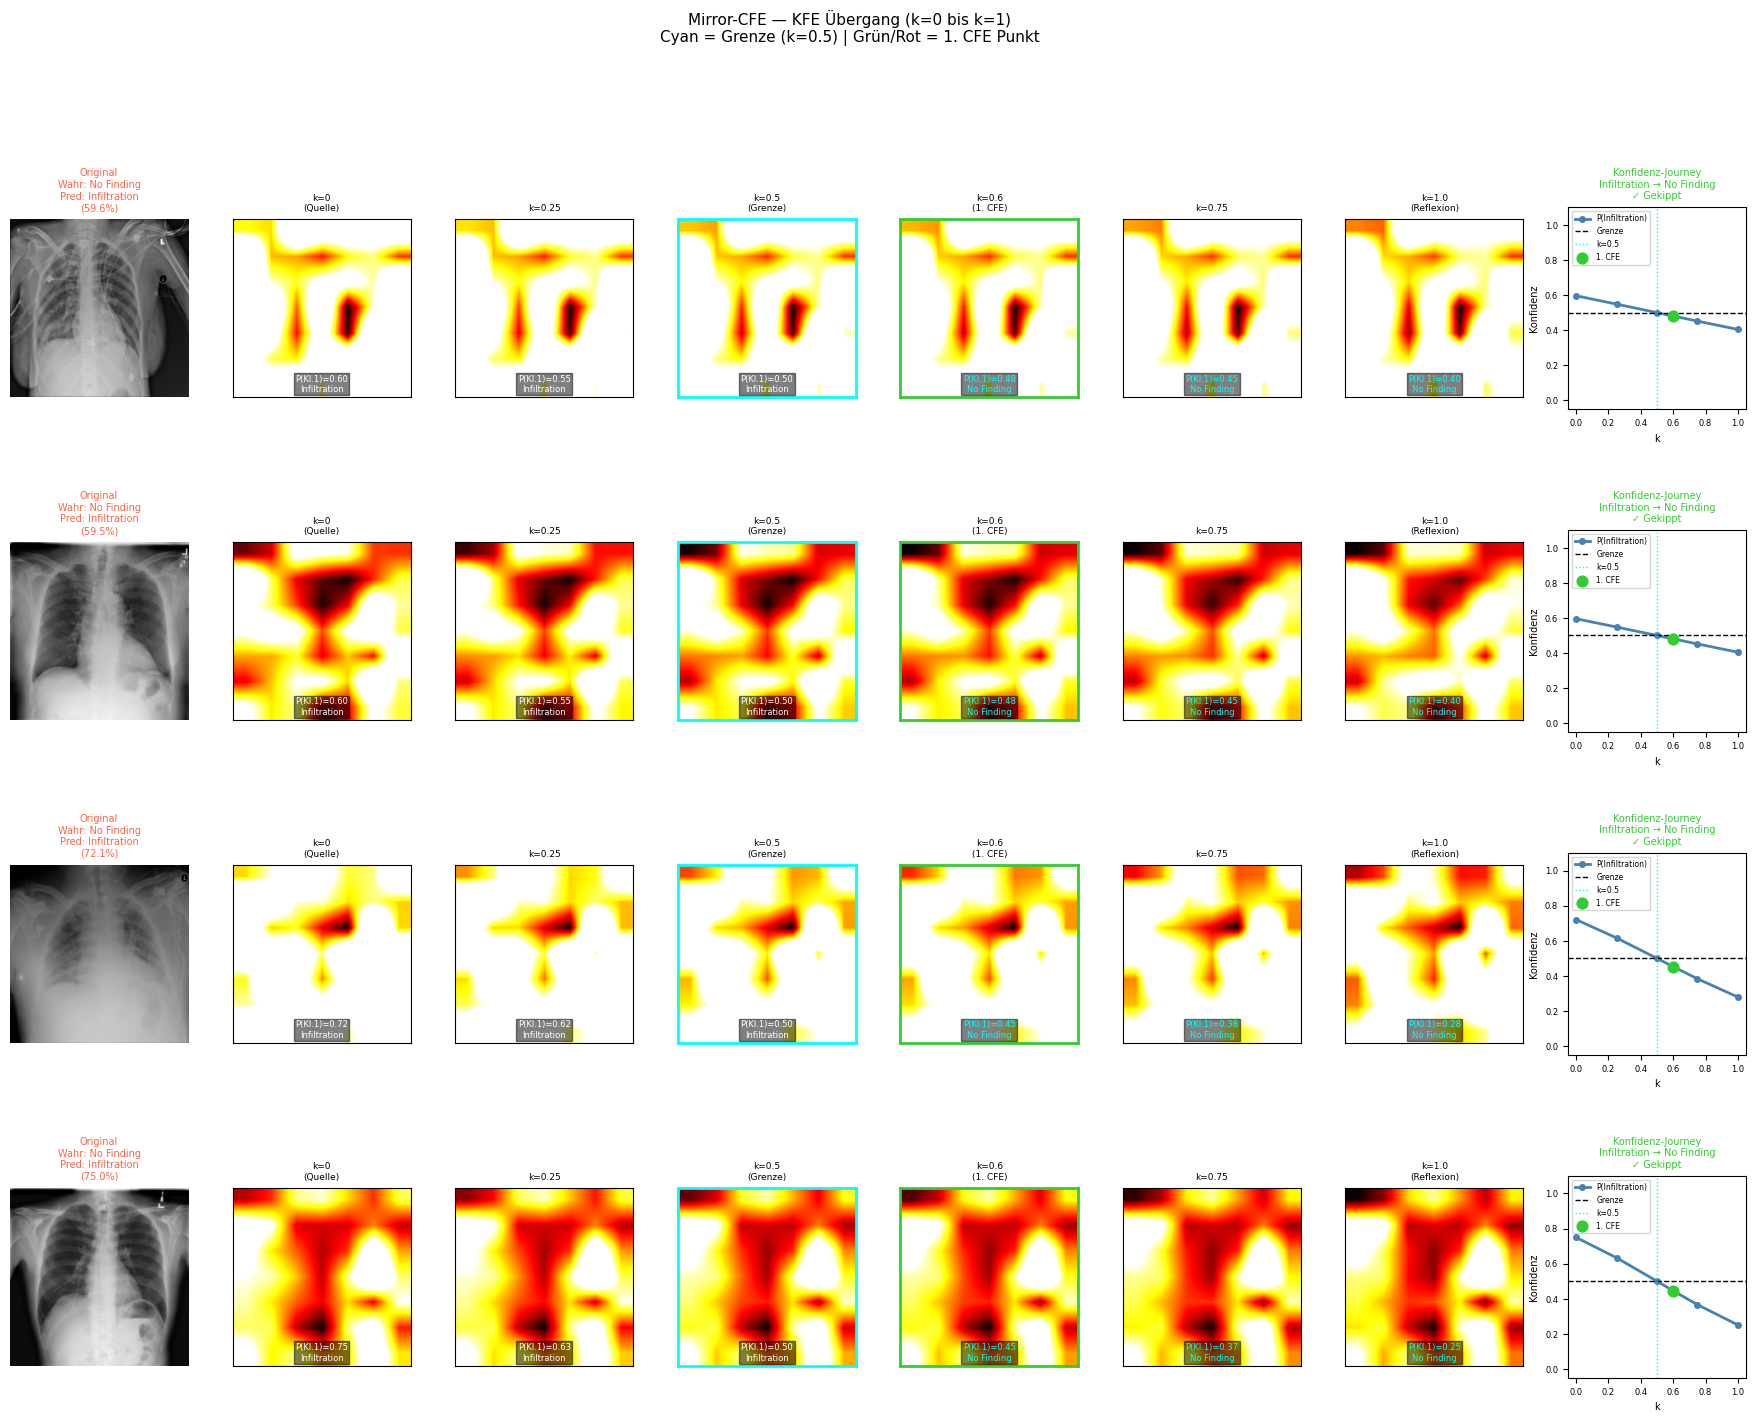

Gespeichert → /kaggle/working/mirror_cfe_xray.png


In [11]:
visualise_cfe(
    model         = model,
    images        = sample_images,
    labels        = sample_labels,
    fnames        = sample_fnames,
    mirror_fv     = mirror_fv,
    cfe_labels    = cfe_labels,
    source_labels = source_labels,
    orig_probs    = orig_probs,
    bbox_lookup   = bbox_lookup,
    class_names   = CLASS_NAMES,
    bbox_class_idx = 1,       # Infiltration hat BBoxen
    bbox_color    = 'yellow',
    n_samples     = 4,
    save_path     = '/kaggle/working/mirror_cfe_xray.png'
)

## 12. Nur Infiltration-Bilder mit BBox

Infiltration-Bilder mit BBox im Test-Set: 11


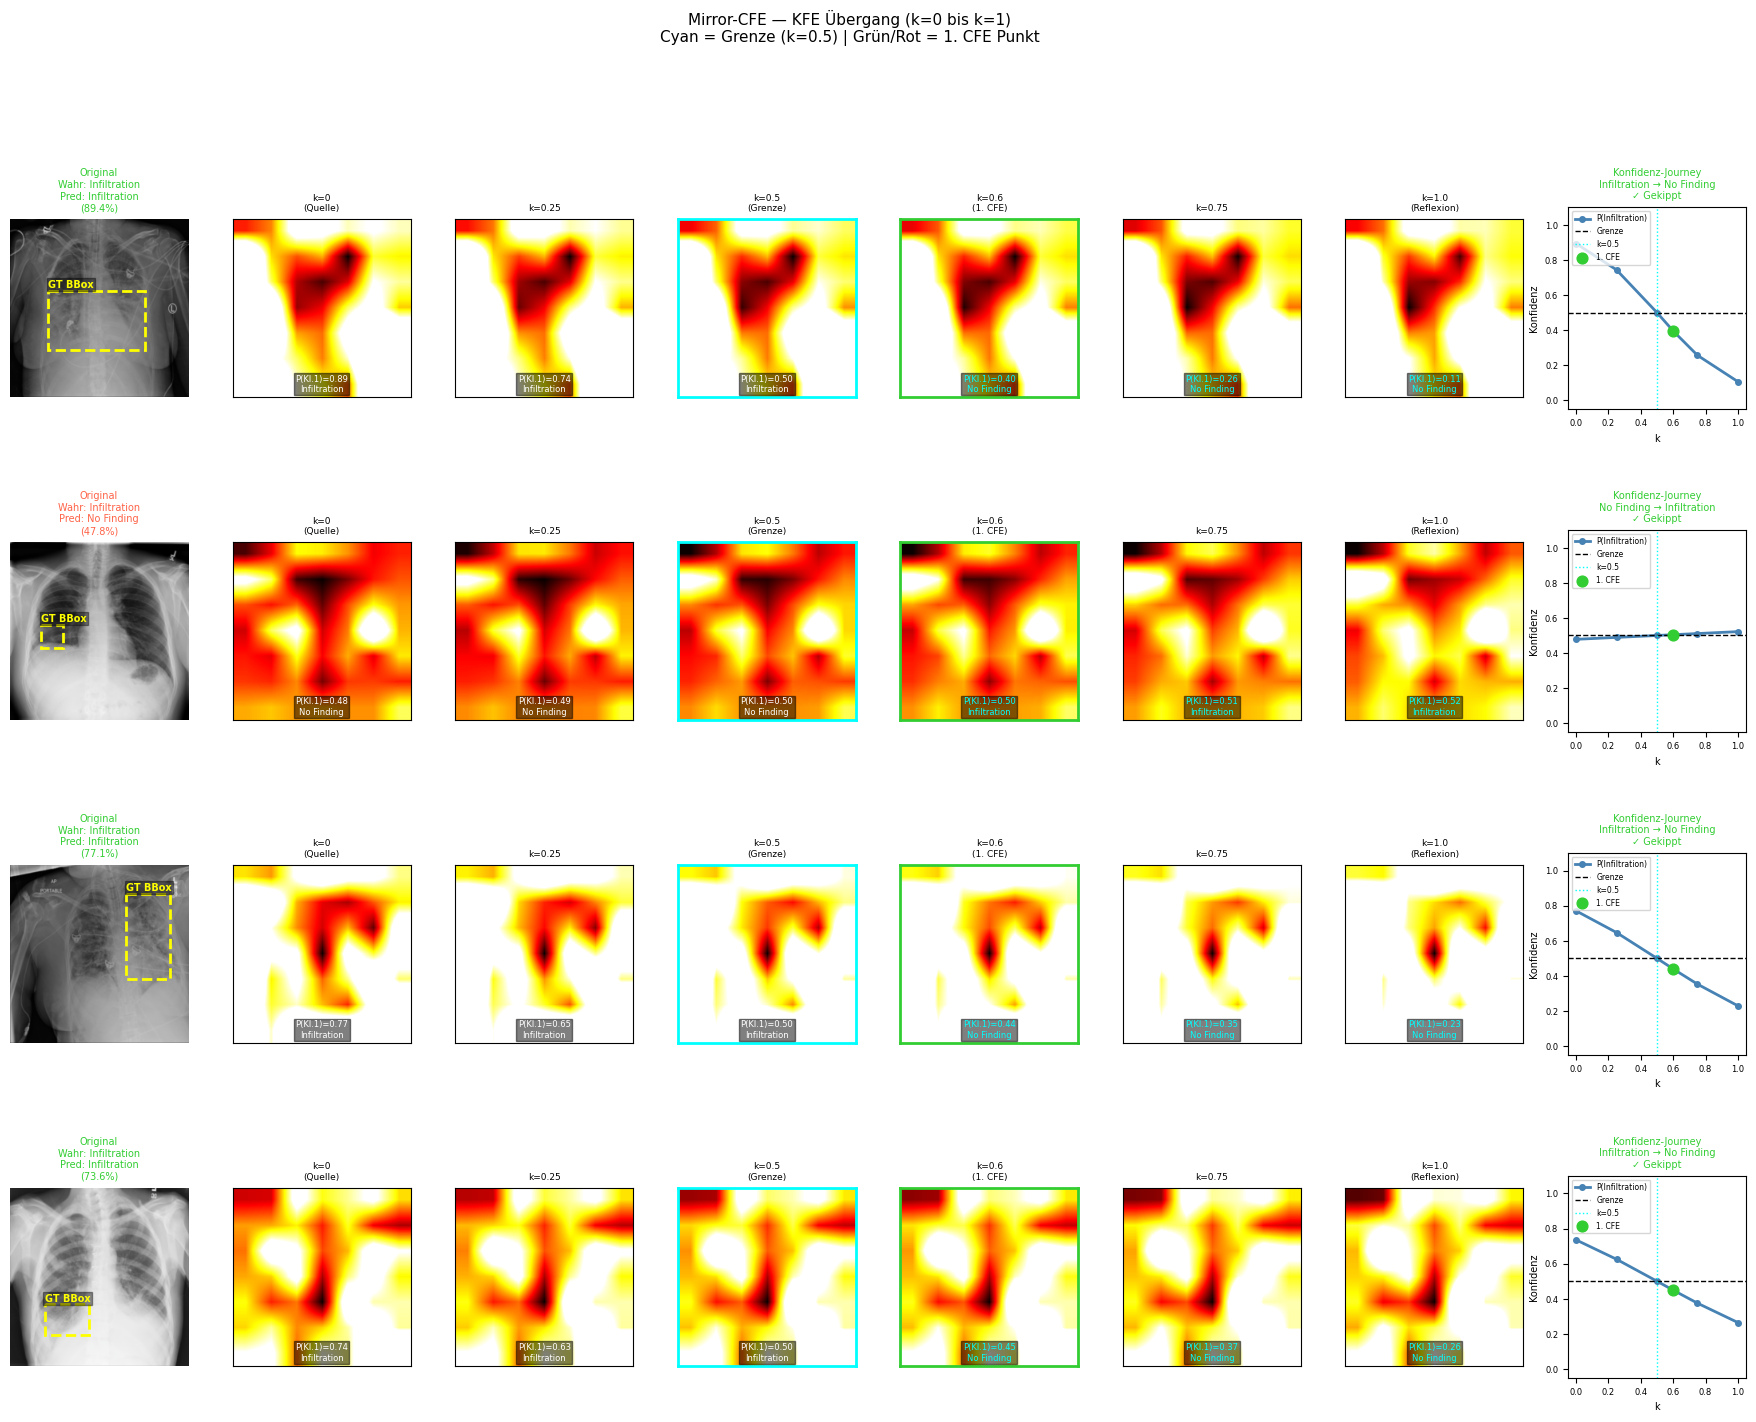

Gespeichert → /kaggle/working/mirror_cfe_xray_bbox.png


In [12]:
bbox_image_names = set(bbox_lookup.keys())
test_with_bbox = test_df[
    (test_df['binary_label'] == 1) &
    (test_df['Image Index'].isin(bbox_image_names))
].reset_index(drop=True)

print(f'Infiltration-Bilder mit BBox im Test-Set: {len(test_with_bbox)}')

if len(test_with_bbox) == 0:
    test_with_bbox = all_xray_df[
        (all_xray_df['binary_label'] == 1) &
        (all_xray_df['Image Index'].isin(bbox_image_names))
    ].reset_index(drop=True)
    print(f'Verwende alle verfügbaren BBox-Bilder: {len(test_with_bbox)}')

bbox_dataset = XRayDataset(test_with_bbox, transform=eval_transforms)
bbox_loader  = DataLoader(bbox_dataset, batch_size=8, shuffle=True,
                          num_workers=2, pin_memory=False)
bbox_imgs, bbox_lbls, bbox_fnames = next(iter(bbox_loader))
m_fv_b, cfe_b, src_b, prob_b = compute_mirror_cfe(
    model, bbox_imgs, DEVICE, num_iterations=20
)
visualise_cfe(
    model=model, images=bbox_imgs, labels=bbox_lbls, fnames=bbox_fnames,
    mirror_fv=m_fv_b, cfe_labels=cfe_b, source_labels=src_b,
    orig_probs=prob_b, bbox_lookup=bbox_lookup, class_names=CLASS_NAMES,
    bbox_class_idx=1, bbox_color='yellow', n_samples=4,
    save_path='/kaggle/working/mirror_cfe_xray_bbox.png'
)

## 13. Batch-Evaluation

In [13]:
n_batches    = 10
total_flip   = 0
total_images = 0

for batch_imgs, batch_lbls, batch_fnames in tqdm(
        list(test_loader)[:n_batches], desc='CFE Evaluation'):
    m_fv, c_lbls, s_lbls, o_probs = compute_mirror_cfe(
        model, batch_imgs, DEVICE, num_iterations=20
    )
    cfe_p = predict_from_features(model, m_fv).cpu()
    preds = (cfe_p >= 0.5).long()
    total_flip   += (preds == c_lbls.cpu()).sum().item()
    total_images += len(batch_lbls)

print(f'\nFlip Rate: {total_flip}/{total_images} = {total_flip/total_images:.2%}')

CFE Evaluation: 100%|██████████| 10/10 [00:05<00:00,  1.76it/s]


Flip Rate: 160/160 = 100.00%


Decoder geladen ✓


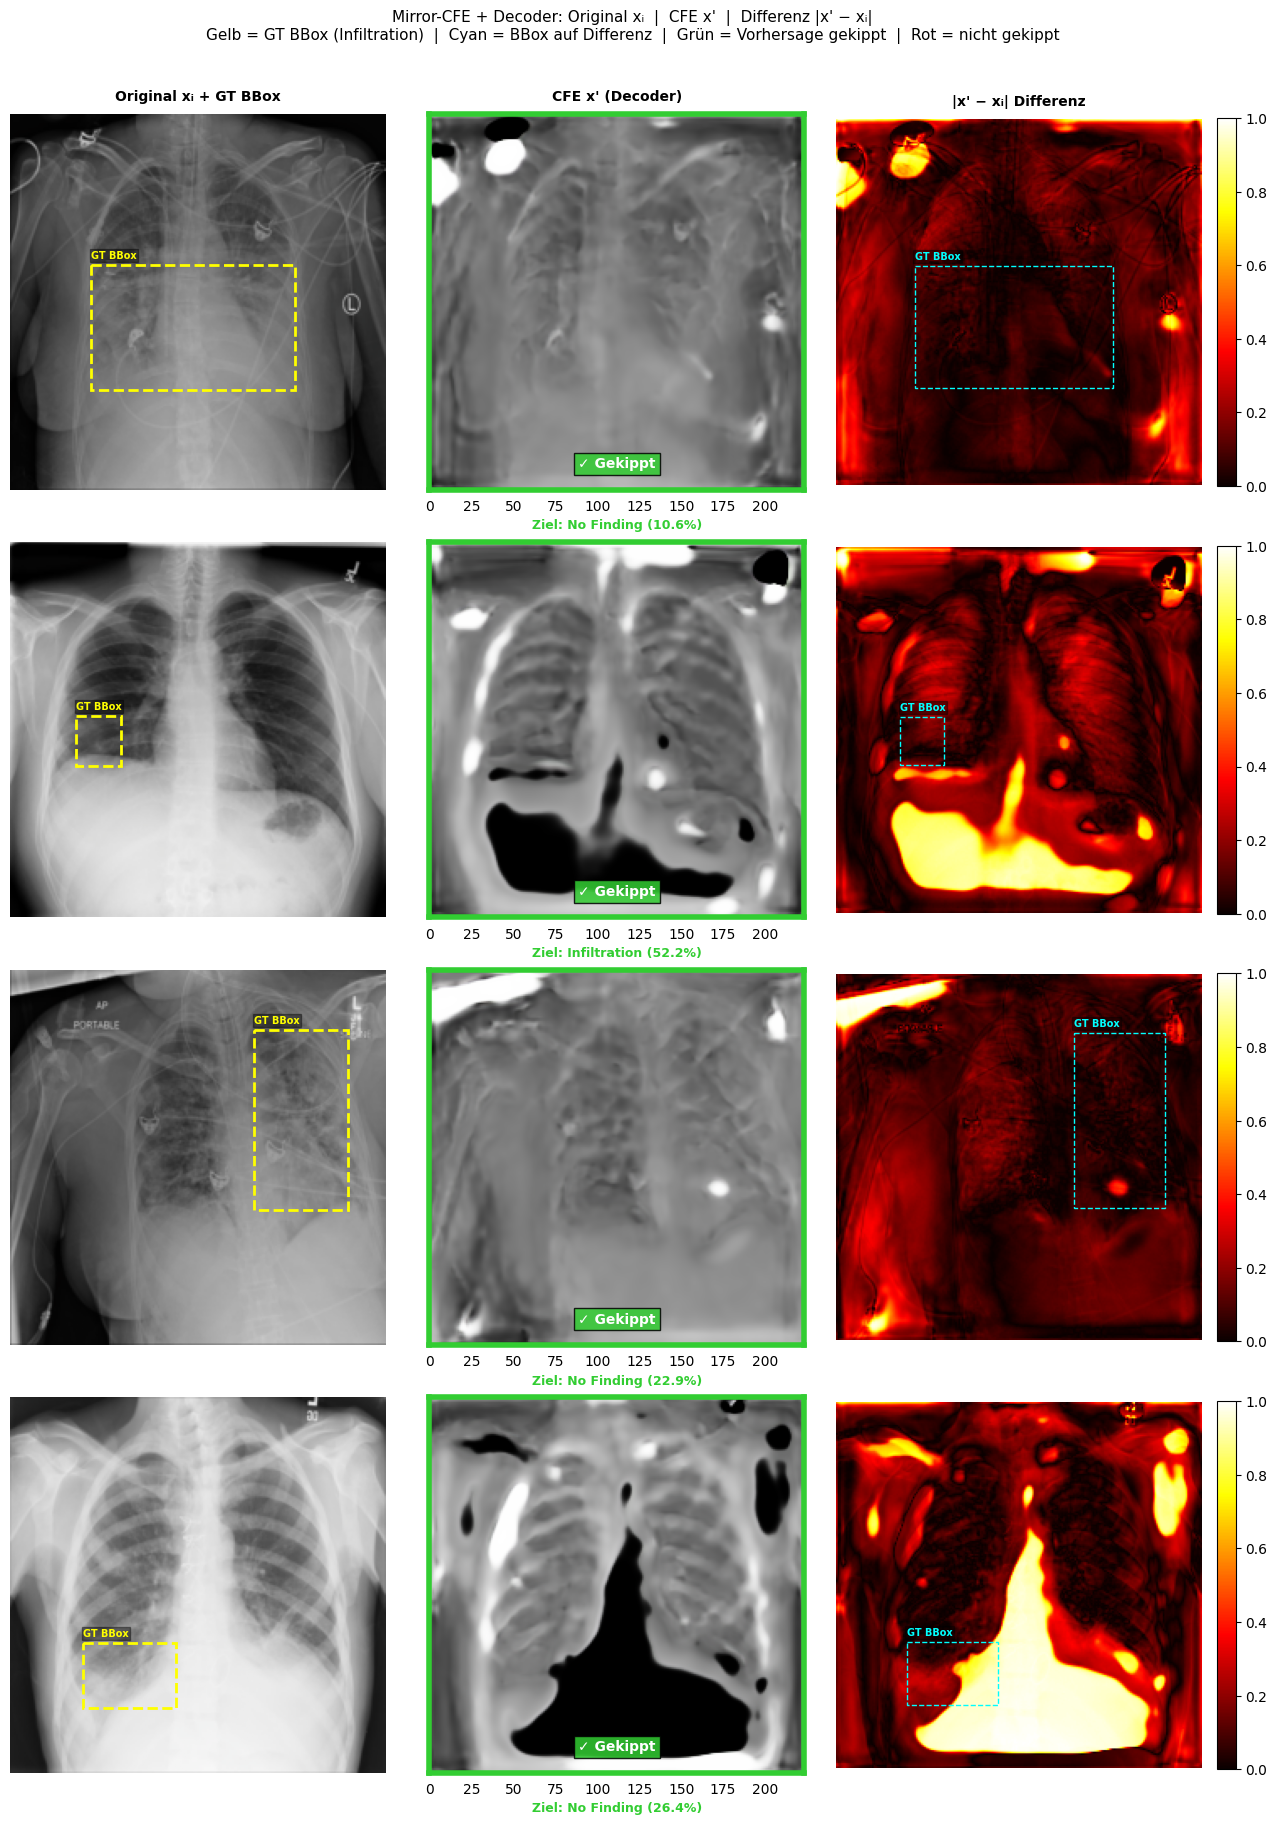

Gespeichert → /kaggle/working/mirror_cfe_decoded_xray.png


In [14]:
class SkipDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.up1 = self._up_block(512, 256)
        self.up2 = self._up_block(512, 128)
        self.up3 = self._up_block(256, 64)
        self.up4 = self._up_block(128, 32)
        self.up5 = self._up_block(32,  16)
        self.out_conv = nn.Sequential(
            nn.Conv2d(16, 3, kernel_size=3, padding=1),
            nn.Tanh()
        )
    def _up_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, f4, f3=None, f2=None, f1=None):
        x = self.up1(f4)
        if f3 is not None: x = torch.cat([x, f3], dim=1)
        x = self.up2(x)
        if f2 is not None: x = torch.cat([x, f2], dim=1)
        x = self.up3(x)
        if f1 is not None: x = torch.cat([x, f1], dim=1)
        x = self.up4(x)
        x = self.up5(x)
        return self.out_conv(x)

def extract_all_features(model, images):
    """Alle 4 ResNet-Ebenen für den Decoder."""
    feats = {}
    hooks = []
    layer_map = {
        'f1': model.encoder.blocks[0],
        'f2': model.encoder.blocks[1],
        'f3': model.encoder.blocks[2],
        'f4': model.encoder.blocks[3],
    }
    for name, layer in layer_map.items():
        h = layer.register_forward_hook(
            lambda m, i, o, n=name: feats.update({n: o})
        )
        hooks.append(h)
    with torch.no_grad():
        _ = model(images)
    for h in hooks:
        h.remove()
    return feats['f1'], feats['f2'], feats['f3'], feats['f4']


def tanh_to_img(tensor):
    """Decoder Output [-1,1] → [0,1]"""
    return (tensor + 1.0) / 2.0


DECODER_PTH = '/kaggle/input/models/alexandernigg/decoder-xray/pytorch/default/1/decoder_xray.pth'

dec_ckpt = torch.load(DECODER_PTH, map_location=DEVICE, weights_only=False)
decoder  = SkipDecoder().to(DEVICE)
decoder.load_state_dict(dec_ckpt['model_state_dict'])
decoder.eval()
print('Decoder geladen ✓')


def visualise_decoder_cfe(model, decoder, images, labels, fnames,
                           mirror_fv, cfe_labels, source_labels,
                           orig_probs, bbox_lookup, class_names,
                           bbox_class_idx=1, bbox_color='yellow',
                           n_samples=4, save_path='mirror_cfe_decoded.png'):
    """
    Drei-Panel Visualisierung pro Sample:
      Panel 1: Original xᵢ  + GT BBox (gelb, nur bei Infiltration-Bildern)
      Panel 2: CFE x'       (Decoder Output aus Mirror-CFE Feature Maps)
      Panel 3: Differenzbild |x' − xᵢ|  (hell = starke Änderung)
    """
    model.eval()
    decoder.eval()
    images = images.to(DEVICE)
    n      = min(n_samples, images.size(0))

    f1, f2, f3, f4 = extract_all_features(model, images[:n])

    with torch.no_grad():
        cfe_imgs = decoder(
            mirror_fv[:n].detach(),
            f3, f2, f1
        )

    cfe_probs_val = predict_from_features(model, mirror_fv[:n]).cpu().numpy()
    orig_probs_np = orig_probs[:n].detach().cpu().numpy()

    fig, axes = plt.subplots(n, 3, figsize=(13, n * 4.5))
    if n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ['Original xᵢ + GT BBox', "CFE x' (Decoder)", "|x' − xᵢ| Differenz"]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=10, fontweight='bold', pad=10)

    for i in range(n):
        orig_np = denormalise(images[i].cpu()).permute(1, 2, 0).numpy()
        cfe_np  = tanh_to_img(cfe_imgs[i].detach().cpu()).permute(1, 2, 0).numpy().clip(0, 1)
        diff_np = np.abs(cfe_np - orig_np).mean(axis=2)
        diff_np = (diff_np - diff_np.min()) / (diff_np.max() + 1e-8)

        src_lbl  = source_labels[i].item()
        cfe_lbl  = cfe_labels[i].item()
        true_lbl = int(labels[i])
        fname    = fnames[i]
        flipped  = int(cfe_probs_val[i] >= 0.5) == cfe_lbl
        has_bbox = fname in bbox_lookup

        flip_col = 'limegreen' if flipped else 'tomato'
        flip_txt = '✓ Gekippt' if flipped else '✗ Nicht gekippt'
        pred_col = 'limegreen' if src_lbl == true_lbl else 'tomato'

        # ── Panel 1: Original + BBox ──────────────────────────────────────────
        ax1 = axes[i, 0]
        ax1.imshow(orig_np)

        # BBox nur bei Infiltration (true_lbl == 1)
        if has_bbox and true_lbl == bbox_class_idx:
            draw_bbox_on_ax(ax1, bbox_lookup, fname, color=bbox_color)
        elif true_lbl == bbox_class_idx:
            ax1.text(5, IMG_SIZE - 8, 'Keine BBox verfügbar',
                     color='orange', fontsize=6,
                     bbox=dict(facecolor='black', alpha=0.5, pad=1))

        ax1.set_ylabel(
            f'Sample {i+1}\n'
            f'{class_names[src_lbl]} → {class_names[cfe_lbl]}\n'
            f'Wahr: {class_names[true_lbl]}',
            fontsize=9, color=pred_col, rotation=0,
            labelpad=110, va='center', fontweight='bold'
        )
        ax1.tick_params(left=False, bottom=False,
                        labelleft=False, labelbottom=False)
        ax1.axis('off')

        # ── Panel 2: CFE-Bild ─────────────────────────────────────────────────
        ax2 = axes[i, 1]
        ax2.imshow(cfe_np)

        for spine in ax2.spines.values():
            spine.set_edgecolor(flip_col)
            spine.set_linewidth(4)
        ax2.set_visible(True)

        ax2.text(0.5, 0.05, flip_txt,
                 transform=ax2.transAxes,
                 ha='center', va='bottom',
                 fontsize=10, fontweight='bold', color='white',
                 bbox=dict(facecolor=flip_col, alpha=0.85, pad=3))

        ax2.set_xlabel(
            f'Ziel: {class_names[cfe_lbl]} ({cfe_probs_val[i]:.1%})',
            fontsize=9, color=flip_col, fontweight='bold'
        )
        ax2.tick_params(left=False, bottom=False,
                        labelleft=False, labelbottom=True)

        # ── Panel 3: Differenzbild ────────────────────────────────────────────
        ax3 = axes[i, 2]
        im  = ax3.imshow(diff_np, cmap='hot', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
        # BBox auf Differenzbild — zeigt ob Änderungen in der annotierten Region liegen
        if has_bbox and true_lbl == bbox_class_idx:
            draw_bbox_on_ax(ax3, bbox_lookup, fname, color='cyan', linewidth=1)
        ax3.axis('off')

    plt.suptitle(
        "Mirror-CFE + Decoder: Original xᵢ  |  CFE x'  |  Differenz |x' − xᵢ|\n"
        "Gelb = GT BBox (Infiltration)  |  Cyan = BBox auf Differenz  |  "
        "Grün = Vorhersage gekippt  |  Rot = nicht gekippt",
        fontsize=11, y=1.01
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Gespeichert → {save_path}')

visualise_decoder_cfe(
    model         = model,
    decoder       = decoder,
    images        = bbox_imgs,        
    labels        = bbox_lbls,        
    fnames        = bbox_fnames,      
    mirror_fv     = m_fv_b,           
    cfe_labels    = cfe_b,            
    source_labels = src_b,            
    orig_probs    = prob_b,           
    bbox_lookup   = bbox_lookup,
    class_names   = CLASS_NAMES,
    bbox_class_idx = 1,
    bbox_color    = 'yellow',
    n_samples     = 4,
    save_path     = '/kaggle/working/mirror_cfe_decoded_xray.png'
)

In [15]:
pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.3 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.

In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# METRIKEN — nach Moreira et al. (2025) und Chowdhury et al. (2025)
# ══════════════════════════════════════════════════════════════════════════════
import time
from scipy import linalg as scipy_linalg

# LPIPS benötigt das lpips Paket
try:
    import lpips
    lpips_fn = lpips.LPIPS(net='squeeze').to(DEVICE)
    lpips_fn.eval()
    LPIPS_AVAILABLE = True
    print('LPIPS geladen ✓')
except ImportError:
    LPIPS_AVAILABLE = False
    print('⚠ lpips nicht verfügbar — pip install lpips')


# ── Hilfsfunktionen ───────────────────────────────────────────────────────────

def get_cfe_image_from_mirror(model, decoder, images, mirror_fv):
    """
    Generiert CFE-Bilder aus Mirror-CFE Feature Maps über den Decoder.
    Rückgabe: cfe_np (B, 224, 224, 3) in [0,1], orig_np (B, 224, 224, 3) in [0,1]
    """
    images = images.to(DEVICE)
    n = images.size(0)
    f1, f2, f3, f4 = extract_all_features(model, images)
    with torch.no_grad():
        cfe_imgs = decoder(mirror_fv[:n].detach(), f3, f2, f1)
    orig_np = denormalise(images.cpu()).permute(0,2,3,1).numpy()
    cfe_np  = tanh_to_img(cfe_imgs.detach().cpu()).permute(0,2,3,1).numpy().clip(0,1)
    return orig_np, cfe_np


# ── 1. L1-Distanz (Proximity) ─────────────────────────────────────────────────
def compute_l1(orig_np, cfe_np):
    """
    L1-Norm nach Wachter et al. (2017).
    Niedrigerer Wert = CF liegt näher am Original.
    """
    C, H, W = orig_np.shape[1], orig_np.shape[2], orig_np.shape[3] \
        if orig_np.ndim == 4 else (3, 224, 224)
    diffs = np.abs(orig_np - cfe_np)             # (B, H, W, 3)
    l1_per_sample = diffs.sum(axis=(1,2,3)) / (orig_np.shape[1] * orig_np.shape[2] * orig_np.shape[3])
    return float(l1_per_sample.mean())


# ── 2. Sparsity Rate (Interpretierbarkeit) ────────────────────────────────────
def compute_sparsity_rate(orig_np, cfe_np, threshold=1e-4):
    """
    Anteil der veränderten Pixel nach Moreira et al. (2025).
    threshold: minimale Änderung damit ein Pixel als verändert gilt.
    Niedrigerer Wert = weniger Pixel verändert = interpretierbarer.
    """
    diff = np.abs(orig_np - cfe_np).mean(axis=-1)   # (B, H, W)
    changed = (diff > threshold).astype(float)
    sparsity_per_sample = changed.mean(axis=(1,2))
    return float(sparsity_per_sample.mean())


# ── 3. LPIPS (Interpretierbarkeit / Perceptual Similarity) ───────────────────
def compute_lpips(orig_np, cfe_np):
    """
    Learned Perceptual Image Patch Similarity nach Zhang et al. (2018).
    Verwendet SqueezeNet wie in Chowdhury et al. (2025).
    Niedrigerer Wert = wahrnehmbar ähnlicher.
    """
    if not LPIPS_AVAILABLE:
        return None
    # [0,1] → [-1,1] für LPIPS
    orig_t = torch.tensor(orig_np, dtype=torch.float32).permute(0,3,1,2).to(DEVICE) * 2 - 1
    cfe_t  = torch.tensor(cfe_np,  dtype=torch.float32).permute(0,3,1,2).to(DEVICE) * 2 - 1
    with torch.no_grad():
        scores = lpips_fn(orig_t, cfe_t)
    return float(scores.mean().cpu())


# ── 4. FID (Plausibilität) — InceptionV3 Features ────────────────────────────
from torchvision.models import inception_v3
from torchvision.transforms.functional import resize

@torch.no_grad()
def extract_inception_features(imgs_np, batch_size=32):
    """
    Extrahiert 2048-dim InceptionV3 Features für FID.
    imgs_np: (B, H, W, 3) in [0,1]
    """
    # InceptionV3 lazy-laden
    if not hasattr(extract_inception_features, '_model'):
        model_inc = inception_v3(weights='DEFAULT', transform_input=False)
        model_inc.fc = nn.Identity()   # 2048 Features statt 1000 Klassen
        model_inc = model_inc.eval().to(DEVICE)
        extract_inception_features._model = model_inc

    inc = extract_inception_features._model
    feats = []

    for i in range(0, len(imgs_np), batch_size):
        batch = imgs_np[i:i+batch_size]
        t = torch.tensor(batch, dtype=torch.float32).permute(0,3,1,2).to(DEVICE)
        # InceptionV3 braucht 299×299
        t = torch.nn.functional.interpolate(t, size=(299,299), mode='bilinear',
                                             align_corners=False)
        feat = inc(t)
        feats.append(feat.cpu().numpy())

    return np.concatenate(feats, axis=0)   # (B, 2048)


def compute_fid(real_np, fake_np):
    """
    FID über InceptionV3 Features (2048-dim) — speichereffizient.
    Niedrigerer Wert = generierte CFs ähneln echter Bildverteilung.
    """
    real_feats = extract_inception_features(real_np)   # (B, 2048)
    fake_feats = extract_inception_features(fake_np)   # (B, 2048)

    mu_r  = real_feats.mean(axis=0)
    mu_f  = fake_feats.mean(axis=0)
    sig_r = np.cov(real_feats, rowvar=False)
    sig_f = np.cov(fake_feats, rowvar=False)

    diff     = mu_r - mu_f
    covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = float(diff @ diff + np.trace(sig_r + sig_f - 2 * covmean))
    return fid


# ── 5. EBPG (Lokalisierung, nur bei BBox-Bildern) ────────────────────────────
def compute_ebpg(orig_np, cfe_np, bboxes_pixel):
    """
    Energy-Based Pointing Game nach Wang et al. (2019), adaptiert für CF-Differenzbilder.
    bboxes_pixel: Liste von {'x','y','w','h'} in Pixel-Koordinaten (224x224)
    EBPG = Energie im BBox-Bereich / Gesamtenergie des Differenzbildes
    Höherer Wert = Änderungen konzentrieren sich auf die annotierte Region.
    """
    scores = []
    for i, bbox in enumerate(bboxes_pixel):
        diff = np.abs(cfe_np[i] - orig_np[i]).mean(axis=-1)   # (H, W)
        total_energy = diff.sum() + 1e-8

        x1 = max(0, int(bbox['x']))
        y1 = max(0, int(bbox['y']))
        x2 = min(224, int(bbox['x'] + bbox['w']))
        y2 = min(224, int(bbox['y'] + bbox['h']))

        bbox_energy = diff[y1:y2, x1:x2].sum()
        scores.append(bbox_energy / total_energy)

    return float(np.mean(scores)) if scores else None


# ── 6. Validity & Denoised Validity (Funktionalität) ─────────────────────────
def compute_validity(model, cfe_imgs_tensor, cfe_labels, denoise_sigma=None):
    """
    Validity nach Verma et al. (2022).
    denoise_sigma: wenn gesetzt → Denoised Validity (Gaussian Blur vor Klassifikation).
    """
    from torchvision.transforms.functional import gaussian_blur

    model.eval()
    cfe_imgs_tensor = cfe_imgs_tensor.to(DEVICE)

    if denoise_sigma is not None:
        kernel_size = int(denoise_sigma * 6) | 1   # ungerade Zahl
        kernel_size = max(kernel_size, 3)
        cfe_blurred = gaussian_blur(cfe_imgs_tensor, kernel_size=[kernel_size, kernel_size],
                                    sigma=[denoise_sigma, denoise_sigma])
    else:
        cfe_blurred = cfe_imgs_tensor

    # CFE-Bilder sind in [0,1] (tanh_to_img Output) — für Classifier re-normalisieren
    mean = torch.tensor(IMAGENET_MEAN, device=DEVICE).view(1,3,1,1)
    std  = torch.tensor(IMAGENET_STD,  device=DEVICE).view(1,3,1,1)
    cfe_norm = (cfe_blurred - mean) / std

    with torch.no_grad():
        logits = model(cfe_norm)
        preds  = logits.argmax(dim=1).cpu()

    validity = (preds == cfe_labels.cpu()).float().mean()
    return float(validity)


# ── 7. Coverage (Funktionalität) ──────────────────────────────────────────────
def compute_coverage(model, images, n_runs=5, num_iterations=20):
    """
    Coverage nach Moreira et al. (2025): wie oft findet der Algorithmus
    ein valides CF? Gemittelt über n_runs Durchläufe.
    """
    images = images.to(DEVICE)
    valid_runs = []

    for run in range(n_runs):
        torch.manual_seed(run)
        m_fv, c_lbls, s_lbls, o_probs = compute_mirror_cfe(
            model, images, DEVICE, num_iterations=num_iterations
        )
        cfe_p = predict_from_features(model, m_fv).cpu()
        preds = (cfe_p >= 0.5).long()
        rate  = (preds == c_lbls.cpu()).float().mean().item()
        valid_runs.append(rate)

    return float(np.mean(valid_runs)), float(np.std(valid_runs))


print('Metrik-Funktionen definiert ✓')

Setting up [LPIPS] perceptual loss: trunk [squeeze], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 4.73M/4.73M [00:00<00:00, 60.1MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/squeeze.pth
LPIPS geladen ✓
Metrik-Funktionen definiert ✓


In [17]:
# ══════════════════════════════════════════════════════════════════════════════
# METRIKEN BERECHNEN — über 5 Batches
# ══════════════════════════════════════════════════════════════════════════════
import time

N_EVAL_BATCHES  = 5
DENOISE_SIGMA   = 1.0   # Gaussian Blur für Denoised Validity

all_l1, all_sparsity, all_lpips = [], [], []
all_real_np, all_cfe_np = [], []
all_eval_imgs = []          # für Coverage über vollen Eval-Satz
all_cfe_tensor, all_cfe_labels = [], []
all_ebpg = []
total_time = 0.0
n_images   = 0

print(f'Berechne Metriken über {N_EVAL_BATCHES} Batches...')
print('-' * 60)

for batch_imgs, batch_lbls, batch_fnames in tqdm(
        list(test_loader)[:N_EVAL_BATCHES], desc='Metrik-Evaluation'):

    t0 = time.time()
    m_fv, c_lbls, s_lbls, o_probs = compute_mirror_cfe(
        model, batch_imgs, DEVICE, num_iterations=20
    )
    total_time += time.time() - t0
    n_images   += len(batch_lbls)
    all_eval_imgs.append(batch_imgs.cpu())

    # CFE-Bilder generieren
    orig_np, cfe_np = get_cfe_image_from_mirror(model, decoder, batch_imgs, m_fv)

    # L1
    all_l1.append(compute_l1(orig_np, cfe_np))

    # Sparsity Rate
    all_sparsity.append(compute_sparsity_rate(orig_np, cfe_np))

    # LPIPS
    if LPIPS_AVAILABLE:
        all_lpips.append(compute_lpips(orig_np, cfe_np))

    # FID Daten sammeln
    all_real_np.append(orig_np)
    all_cfe_np.append(cfe_np)

    # Validity Tensoren sammeln
    # cfe_np ist in [0,1] → zu Tensor
    cfe_t = torch.tensor(cfe_np, dtype=torch.float32).permute(0,3,1,2)
    all_cfe_tensor.append(cfe_t)
    all_cfe_labels.append(c_lbls.cpu())

    # EBPG — nur für fire-Bilder mit BBox
    batch_bboxes = []
    batch_valid  = []
    for i, fname in enumerate(batch_fnames):
        if fname in bbox_lookup and int(batch_lbls[i]) == 1:
            batch_bboxes.append(bbox_lookup[fname])
            batch_valid.append(i)
    if batch_bboxes:
        ebpg = compute_ebpg(orig_np[batch_valid], cfe_np[batch_valid], batch_bboxes)
        if ebpg is not None:
            all_ebpg.append(ebpg)

# ── FID (über alle Batches zusammen) ─────────────────────────────────────────
real_all = np.concatenate(all_real_np, axis=0)
cfe_all  = np.concatenate(all_cfe_np,  axis=0)
fid_score = compute_fid(real_all, cfe_all)

# ── Validity & Denoised Validity ─────────────────────────────────────────────
all_cfe_tensor_cat = torch.cat(all_cfe_tensor, dim=0)
all_cfe_labels_cat = torch.cat(all_cfe_labels, dim=0)

validity          = compute_validity(model, all_cfe_tensor_cat, all_cfe_labels_cat)
denoised_validity = compute_validity(model, all_cfe_tensor_cat, all_cfe_labels_cat,
                                     denoise_sigma=DENOISE_SIGMA)

# ── Coverage ──────────────────────────────────────────────────────────────────
print('Berechne Coverage (5 Runs)...')
eval_imgs_cat = torch.cat(all_eval_imgs, dim=0)
coverage_mean, coverage_std = compute_coverage(
    model, eval_imgs_cat, n_runs=5, num_iterations=20
)

# ── Efficiency ────────────────────────────────────────────────────────────────
efficiency = total_time / n_images   # Sekunden pro CF

print('\n' + '═' * 60)
print('METRIK-ERGEBNISSE — Mirror-CFE Fire Detection')
print('═' * 60)
print(f'\n── Proximity ───────────────────────────────────────────')
print(f'  L1-Distanz:           {np.mean(all_l1):.4f}  (↓ besser)')

print(f'\n── Interpretierbarkeit ─────────────────────────────────')
print(f'  Sparsity Rate:        {np.mean(all_sparsity):.4f}  (↓ besser)')
if LPIPS_AVAILABLE:
    print(f'  LPIPS (SqueezeNet):   {np.mean(all_lpips):.4f}  (↓ besser)')
else:
    print(f'  LPIPS:                nicht verfügbar')

print(f'\n── Plausibilität ───────────────────────────────────────')
print(f'  FID:                  {fid_score:.2f}   (↓ besser)')

if all_ebpg:
    print(f'\n── Lokalisierung (BBox-Bilder) ─────────────────────────')
    print(f'  EBPG:                 {np.mean(all_ebpg):.4f}  (↑ besser)')
    print(f'  Anzahl BBox-Samples:  {sum(len(b) for b in [all_ebpg])}')

print(f'\n── Funktionalität ──────────────────────────────────────')
print(f'  Validity:             {validity:.2%}  (↑ besser)')
print(f'  Denoised Validity:    {denoised_validity:.2%}  (↑ besser, σ={DENOISE_SIGMA})')
print(f'  Δ Validity:           {validity - denoised_validity:.2%}  (↓ besser = weniger adversarial)')
print(f'  Coverage:             {coverage_mean:.2%} ± {coverage_std:.2%}  (↑ besser)')
print(f'  Efficiency:           {efficiency:.3f}s / CF  (↓ besser)')
print('═' * 60)

Berechne Metriken über 5 Batches...
------------------------------------------------------------


Metrik-Evaluation: 100%|██████████| 5/5 [00:03<00:00,  1.43it/s]


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 190MB/s] 
/tmp/ipykernel_23/1634418297.py:125: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)


Berechne Coverage (5 Runs)...

════════════════════════════════════════════════════════════
METRIK-ERGEBNISSE — Mirror-CFE Fire Detection
════════════════════════════════════════════════════════════

── Proximity ───────────────────────────────────────────
  L1-Distanz:           0.1673  (↓ besser)

── Interpretierbarkeit ─────────────────────────────────
  Sparsity Rate:        0.9994  (↓ besser)
  LPIPS (SqueezeNet):   0.3407  (↓ besser)

── Plausibilität ───────────────────────────────────────
  FID:                  220.76   (↓ besser)

── Funktionalität ──────────────────────────────────────
  Validity:             28.75%  (↑ besser)
  Denoised Validity:    30.00%  (↑ besser, σ=1.0)
  Δ Validity:           -1.25%  (↓ besser = weniger adversarial)
  Coverage:             100.00% ± 0.00%  (↑ besser)
  Efficiency:           0.036s / CF  (↓ besser)
════════════════════════════════════════════════════════════
